# TASK 1

## Unit of measure from the features
- Whole_weight, Shucked_weight, Viscera_weight, Shell_weight = **Grams (g)**
- Length,Diameter, Height = **Millimetres (mm)**
- Rings = **Count = Int**
- Sex = **N/A**

## Import Libraries

In [1]:
# Import libraries
import pandas as pd                                                # Manipulate data
import numpy as np                                                 # Numeric operations
import matplotlib.pyplot as plt                                    # Visualization library
import seaborn as sns                                              # Visualization library more friendly

import warnings
warnings.filterwarnings("ignore")                                   # Ignore warnings

from sklearn.metrics import mean_absolute_error                     # MAE metric
from sklearn.metrics import mean_squared_error                      # MSE metric
from sklearn.metrics import r2_score                                # R² metric

## Load the data

In [2]:
df = pd.read_csv("abalone.csv")        # Load the data

df                                     # Display the 5 first and last 5 rows

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4175,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4176,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4177,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4178,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


## Get extra information about the data

In [3]:
# overview of the type of each column, number of rows and columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4180 non-null   str    
 1   Length          4180 non-null   float64
 2   Diameter        4180 non-null   float64
 3   Height          4172 non-null   float64
 4   Whole_weight    4180 non-null   float64
 5   Shucked_weight  4175 non-null   float64
 6   Viscera_weight  4175 non-null   float64
 7   Shell_weight    4180 non-null   float64
 8   Rings           4180 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 298.1 KB


In [4]:
# Summary statistics of the numeric columns
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4180.000000,4180.000000,4172.000000,4180.000000,4175.000000,4175.000000,4180.000000,4180.000000
mean,0.523927,0.407827,0.139494,0.828459,0.359339,0.180621,0.238759,9.933014
std,0.120096,0.099247,0.041822,0.490379,0.222031,0.109620,0.139197,3.224667
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441375,0.186000,0.093250,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.233750,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.328625,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


### Based on this statistical summary, we see that:

There are very different ranges between features:

| Feature | Min | Max |
|---|---|---|
| **Length** | 0.075 | 0.815 |
| **Diameter** | 0.055 | 0.65 |
| **Shucked_weight** | 0.001 | 1.488 |
| **Whole_weight** | 0.002 | 2.825 |
| **Viscera_weight** | 0.0005 | 0.76 |
| **Shell_weight** | 0.0015 | 1.005 |
| **Height** | 0 | 1.130 |

> **Height** — 75% of the data is below **0.165**, despite the maximum being **1.130**

> **Rings** — although the mean is **9.93** and the median is **9**, the maximum value is **29**, much higher than the 75th percentile (**11**)

---

> The fact that the features have different units of measurement is another good reason for using the **Standard Scaler**.

## Check if there are null values on the data

In [5]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            8
Whole_weight      0
Shucked_weight    5
Viscera_weight    5
Shell_weight      0
Rings             0
dtype: int64

Text(0.5, 1.0, 'Viscera_weight')

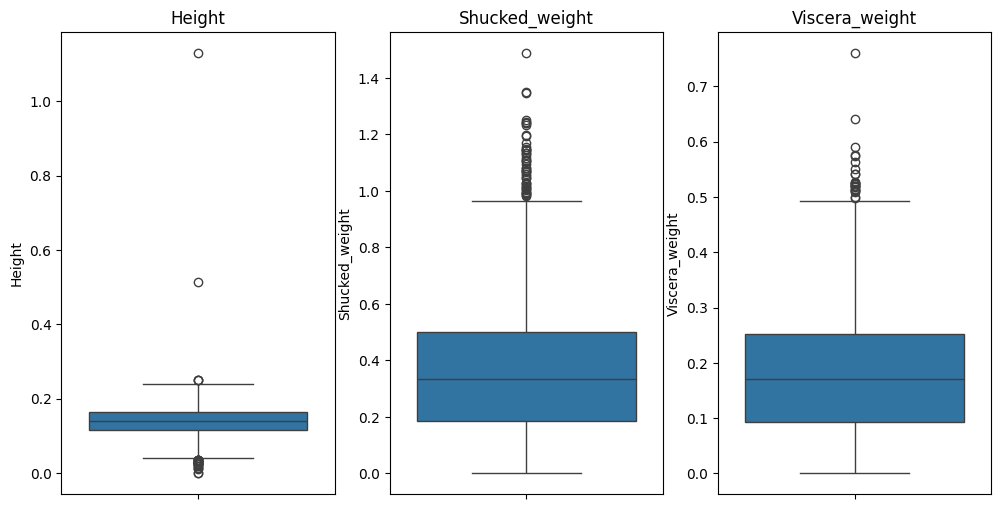

In [6]:
# Plot the columns with null values to understand the distribution
fig, axes = plt.subplots(1,3, figsize=(12,6))

sns.boxplot(y=df["Height"], ax = axes[0])
axes[0].set_title("Height")

sns.boxplot(y=df["Shucked_weight"], ax = axes[1])
axes[1].set_title("Shucked_weight") 

sns.boxplot(y=df["Viscera_weight"], ax = axes[2])
axes[2].set_title("Viscera_weight") 

#### As can be seen in the plots, in addition to the positive skewness, there are outliers; therefore, the median is the best way to fill in the null values.

In [7]:
# There are outliers and extreme values in all these columns, for this reason, I will use Median to replace the null values
df["Height"] = df["Height"].fillna(df["Height"].median())
df["Shucked_weight"] = df["Shucked_weight"].fillna(df["Shucked_weight"].median())
df["Viscera_weight"] = df["Viscera_weight"].fillna(df["Viscera_weight"].median())

In [8]:
# Check if all  the null values were replaced
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

## Check duplicate values

In [9]:
# Before drop
print(f"rows/columns before drop: {df.shape}")

# Drop the duplicated values
df = df.drop_duplicates()

# After drop
print(f"rows/columns after drop: {df.shape}")

rows/columns before drop: (4180, 9)
rows/columns after drop: (4177, 9)


## Encode Data

In [10]:
# I will use LabelEncoder, because ordinal encoder has an idea of hierarchy, that is not the case and OneHotEncoder will add more 3 columns on data 

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in df.select_dtypes(include = [object]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print(le.classes_)                                                  # Display the sequence to identify 0(F),1(I),2(M)

['F' 'I' 'M']


#### This step is important because before training the model, it's important to ensure that all features in the dataset are numeric.

In [11]:
df.head(5)

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,2,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,2,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,0,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,2,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,1,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 4177 entries, 0 to 4179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 326.3 KB


## Understanding the features distribution

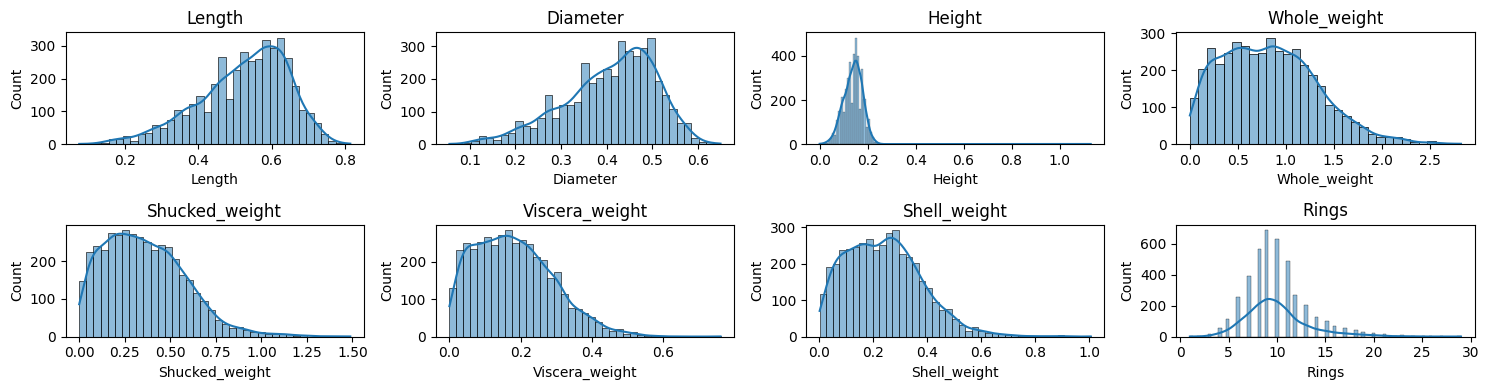

In [13]:
df.columns

# Name of the features
cols = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings']

fig, axes = plt.subplots(2,4, figsize = (15,4))

# Converts a 2D matrix to one-dimensional
axes = axes.flatten()

# Loop to plot each column from the array cols
for i, col in enumerate(cols):
    sns.histplot(df[col], kde =True, ax = axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Features Distribution Analysis

#### Length
Slight right skewness, with most values between **0.5 and 0.7**.

Smaller abalones appear less frequently in the dataset.

#### Diameter
Follows the same pattern as **Length**, with values mainly between **0.35 and 0.5**.

Not surprising length and diameter tend to grow together.

#### Height
Most values are quite low, rarely exceeding **0.2**.

Unlike the other characteristics, height seems to have a natural maximum limit, which makes sense considering the species limitations.

#### Whole Weight
Right skewness with a long tail extending to **2.5**.

Most abalones in the dataset are lighter, meaning there's still a lot of growth ahead for most of them.

#### Shucked Weight
Very similar shape to **Whole Weight**, just with a shorter tail up to **1.5**.

The two clearly measure related things.

#### Viscera Weight
Also with right skewness, but the values remain quite low (mostly between **0 and 0.3**).

The long tail is present, but the numbers themselves don't increase that much.

#### Shell Weight
Looks very similar to **Viscera Weight** and honestly, to most of the other weight columns as well. They all seem to move together.

#### Rings
Stands out from the others. Unlike the other features, the distribution is more discrete, since the values are whole numbers.

Most abalones have between **7 and 15 rings**, with older ones being rare.

----------

### General Observations

- **Height** is clearly the most physically limited characteristic; a flat shell can only reach a maximum height.

- **Weight** characteristics are similar to each other, which we will check in the heatmap.

- Long tails in most characteristics indicate that there are abalones of all sizes, although the smaller ones are the majority.

- Overall, the positive asymmetry in almost all characteristics makes sense for a single species:

- Most individuals cluster around similar sizes, with a smaller group of larger and older individuals that increase in tail size.

## Correlation

Text(0.5, 1.0, 'Correlation between the features')

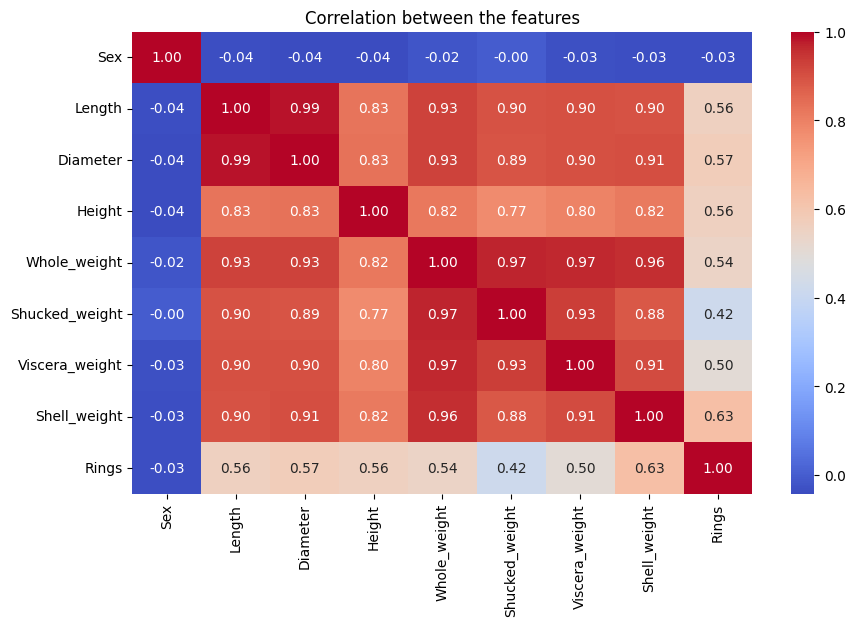

In [14]:
# Plot the correlation between the features
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between the features")

### Observations
- Multicollinearity can become a problem for the model's performance.


#### Length and Diameter
Both features show a **very high correlation with each other (0.99)**,
which was expected as seen in the distribution graphs.

---

#### Weight Features
**Whole_weight**, **Shucked_weight**, **Viscera_weight**, and **Shell_weight**
are all **strongly correlated** with each other (ranging from **0.88 to 0.97**).

This confirms the pattern identified in the histogram analysis, where all weight features shared similar shapes and long tails.

---

#### Height
Despite having **less variability** among all features, Height still has a **moderate-high correlation** with the other physical features (**0.77 – 0.83**).

---

#### Rings
The **Rings** feature shows a **moderate correlation** with the physical characteristics (**0.42 – 0.63**),
with the highest correlation with **Shell_weight (0.63)**.

---

#### Sex
The **Sex** feature shows a correlation **close to zero** with all other traits (ranging from **-0.04 to -0.00**), indicating that it has little to no linear relationship with the physical characteristics of abalone.

Since **Rings** is now the target feature, **Sex** becomes one of the predictors. Despite its low correlation with the remaining features, it was retained in the model as it may still help distinguish younger abalones from adults, given that infants tend to present  significantly smaller size and weight measurements.

## Split the data in X(independent) and y(target)

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("Rings", axis = 1)                    # Independent variables
y = df["Rings"]                                   # Target variable

print(f"X size: {X.shape}")
print(f"y size: {y.shape}")

X size: (4177, 8)
y size: (4177,)


In [16]:
# Understanding with more detail the values in the feature target
df["Rings"].describe()

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64

### Describe Analysis
- 25% of the abalone sample has up to 8 rings


- 50% of the abalone sample has up to 9 rings


- 75% of the abalone sample has up to 11 rings


- Considering that the IQR is (Q1 = 8, Q3 = 11 rings), it shows that the majority of the sample data is concentrated in this range


- The fact that the minimum is 1 and the maximum is 29 indicates the presence of outliers, which can negatively influence the model's performance


- It also indicates a possible positive skewness, however, to confirm this statement, I need to plot a histogram

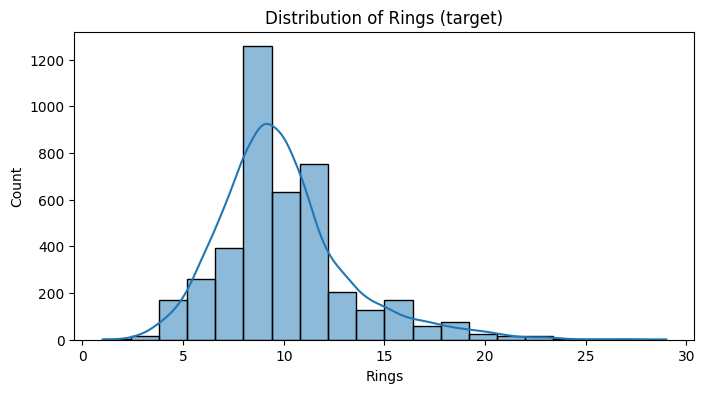

In [17]:
# Plot the distribution of the target feature(Rings)
plt.figure(figsize=(8, 4))
sns.histplot(df["Rings"], bins=20, kde=True)
plt.title("Distribution of Rings (target)")
plt.xlabel("Rings")
plt.ylabel("Count")
plt.show()

### Plot Analysis
- The concentration of data between 8-11 is confirmed, with approximately more than 2600 samples along with the positive skewness.

- The tail lengthens from 15 to 29, despite being a small percentage of the total sample size.

## Normalize the data

In [18]:
# Scaling X data, this step is important because we have a different range between the values on these columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns = X.columns)

print(X_scaled)

           Sex    Length  Diameter    Height  Whole_weight  Shucked_weight  \
0     1.151980 -0.574558 -0.432149 -1.065452     -0.641898       -0.608212   
1     1.151980 -1.448986 -1.439929 -1.185125     -1.230277       -1.171596   
2    -1.280690  0.050033  0.122130 -0.108069     -0.309469       -0.463985   
3     1.151980 -0.699476 -0.432149 -0.347415     -0.637819       -0.648775   
4    -0.064355 -1.615544 -1.540707 -1.424470     -1.272086       -1.216666   
...        ...       ...       ...       ...           ...             ...   
4172 -1.280690  0.341509  0.424464  0.609967      0.118813        0.047567   
4173  1.151980  0.549706  0.323686 -0.108069      0.279929        0.358555   
4174  1.151980  0.632985  0.676409  1.567350      0.708212        0.748416   
4175 -1.280690  0.841182  0.777187  0.250949      0.541998        0.773205   
4176  1.151980  1.549052  1.482634  1.328004      2.283681        2.641386   

      Viscera_weight  Shell_weight  
0          -0.727204     -

#### As we saw above in the statistical summary, in addition to several different units of measurement in the features, the distance between the values is also very high. This hinders the model from identifying patterns and, consequently, from predicting correctly.

## Split Training & Test

In [19]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,                                             # Feature matrix (independent variables)
    y,                                                    # Target variable (dependent variable)
    test_size = 0.25,                                     # 25% of data used for testing, 75% for training
    random_state = 42,
    shuffle = True,                                       
    )

X_train.shape,X_test.shape,y_train.shape,y_test.shape

((3132, 8), (1045, 8), (3132,), (1045,))

## Implement Neural Network

In [20]:
# Import required libraries
import tensorflow
import random
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasRegressor                                       # Import Keras Regressor
from sklearn.model_selection import GridSearchCV, KFold                            # Import Grid Search CV and KFold


tensorflow.random.set_seed(9)                                                      # Set TensorFlow random seed
np.random.seed(1)                                                                  # Set NumPy random seed
random.seed(1)                                                                     # Set Python's built-in random seed

In [21]:
# Compile the model before training
# Import the Sequential model class from Keras
from keras.models import Sequential

# This step configures the model’s learning process
from tensorflow.keras.optimizers import Adam                                 # Import Adam optimizer

n_cols = X_train.shape[1]                                                    # Define n_cols as a dynamic variable

def build_model(hidden_units = 16, learning_rate=0.001): 
    model = Sequential()                                                     # Initialize a Sequential model (a linear stack of neural network layers)
    model.add(Dense(hidden_units, activation="relu", input_shape=(n_cols,))) # Add the first hidden layer
    model.add(Dense(hidden_units, activation="relu"))                        # Add the second hidden layer
    model.add(Dense(hidden_units, activation="relu"))                        # Add the third hidden layer
    model.add(Dense(1))                                                      # Add the output layer
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),                         # Optimization algorithm (Adam = Adaptive Moment Estimation)
        loss="mean_squared_error",                                           # Loss function for regression problems
        metrics=["mae"])                                                     # Metric to evaluate model performance
    return model

# To train our MLP model defined in earlier steps, let's call the fit function.
model = build_model()                                      # build the model

# Train the model for 100 epochs. This value was found using grid_search_cv
model.fit(X_train, y_train, epochs = 100, batch_size = 16)

# Wrap the neural network model
nn_model = KerasRegressor(                                 # Create sklearn-compatible NN model
    model = build_model,                                   # Pass the build_model function
    verbose=0                                              # Suppress training output during grid search
)

# Define hyperparameter grid (used to find the best parameters)
param_grid = {
    "model__hidden_units": [16, 32],                       # Number of neurons in hidden layer
    "model__learning_rate": [0.01, 0.001],                 # Learning rate for Adam optimizer
    "batch_size": [16, 32],                                # Number of samples per gradient update
    "epochs": [50, 100],                                   # Number of training iterations
}                         


# Initialize GridSearchCV
grid_nn = GridSearchCV(
    estimator= nn_model,                                   # The wrapped neural network model
    param_grid=param_grid,                                 # Hyperparameter combinations to evaluate
    cv=KFold(n_splits=5, shuffle=True, random_state=42),   # 5-fold cross-validation
    scoring="neg_mean_squared_error",                      # Use MSE to select best model
    verbose=1                                              # Display the progress of the process 
)

# Fit the model to training data
grid_nn.fit(X_train, y_train)                              # Perform grid search over parameter combinations

# Retrieve best model
best_model = grid_nn.best_estimator_                       # Get model with best hyperparameters

# Make predictions on test data
y_pred = best_model.predict(X_test)                        # Predict ring count for test set

# Display results
print("\nBest Parameters:", grid_nn.best_params_)          # Show optimal hyperparameters
print("\nBest CV Score:", grid_nn.best_score_)             # Show best cross-validation accuracy

# Evaluate Test Data
y_pred = grid_nn.best_estimator_.predict(X_test)

print("MAE: ",  round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:",  round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
print("R²:  ",  round(r2_score(y_test, y_pred), 4))

Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 42.7362 - mae: 5.1455
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11.0673 - mae: 2.1634
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0830 - mae: 1.8075
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1590 - mae: 1.7220
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.5725 - mae: 1.6701
Epoch 6/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.1591 - mae: 1.6346
Epoch 7/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.8525 - mae: 1.6088
Epoch 8/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.6026 - mae: 1.5896
Epoch 9/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.4054 - mae: 1.5744
Epoch 10/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.2448 - mae: 1.5623
Epoch 11/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.1117 - mae: 1.5525
Epoch 12/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.0050 - mae: 1.5455
Epoch 13/10

### Interpreting the Model

---

#### Model

With the goal of predicting the number of abalone rings, a **Multilayer Perceptron (MLP)** was implemented using the **Keras** and **TensorFlow** libraries. The sequential architecture allows us to build the model in a sequence of steps. These steps include:
- 3 hidden **ReLU** activation layers, and a **linear** output layer, since the model has a regression prediction to make.

---

#### What is ReLU?

A **non-linear activation function** that allows the model to understand more complex data patterns.

This happens because if the data is positive, the same value is returned; if it is negative, the function returns 0.
This allows it to understand very complex data and, at the same time, be efficient, because, as mentioned, with negative values, the value 0 causes many neurons not to be activated. The fact that it is simple and efficient makes it the most widely used function.

However, there are **disadvantages**:
- In the case of many 0s (negative values), many neurons may become inactive, thus they no longer learn.
- The gradient *(the model's compass, that which indicates the direction the model should take)* can be unstable during training, especially if there are problems with the weights.

---

#### What is Linear *(the default activation of the output layer)*?

Basically, this function returns the value that was passed — for example, if the value of 10 rings was passed, this function will return 10.

> **This is why it is not implemented in the hidden layers** since it restricts learning because the network would be trained linearly, rendering the other layers useless.

---

#### Parameters

The initial parameters configured (`hidden_units` and `learning_rate`) in the hidden layers of the network were **adjustable**, considering that Grid Search was implemented, which returns the best parameters.

**Optimizer — Adam**
- Adam has an adaptive learning method that allows the model to correct bias frequently so if it makes a significant error, whether too high or too low, it can adjust the bias and weight to be very efficient.
- Because of this dynamic and consequently efficient learning, it doesn't always return the best result, a good result might be enough for it to take as a standard.
- Even so, its efficiency and dynamism make it a good optimizer.

> Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 53.3424 - mae: 6.0025

> Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10.4992 - mae: 2.2285

> Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7441 - mae: 1.7725

> Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.8488 - mae: 1.6889

> Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.4173 - mae: 1.6476

- See the example above, as the MAE decreases and stabilizes, the loss also drops more gradually, indicating that the model is converging that is, this illustrates well how dynamic learning works.
---

#### Grid Search + Cross-Validation

Grid Search with **5-fold cross-validation** was implemented; that is, the training data was divided into **5 equal parts**.
After that, the model trains some parts and tests the remaining part. This process is done **5 times**, so that the average is calculated and the performance is returned *(in this case, Mean Squared Error was used)*.

**Initial Configuration:**

| Parameter | Values tested |
|---|---|
| `hidden_units` | 16, 32 |
| `learning_rate` | 0.01, 0.001 |
| `batch_size` | 16, 32 |
| `epochs` | 50, 100 |

As the model itself returned: 16 combinations × 5 folds = **80 training sessions** in total.

**Best parameters returned by Grid Search:**

| Parameter | Optimal value |
|---|---|
| `hidden_units` | 16 |
| `learning_rate` | 0.001 |
| `batch_size` | 16 |
| `epochs` | 100 |

The values chosen for each parameter were deliberately kept small and focused:

- **hidden_units (16)** — Avoids overfitting; a value of 32 or higher would possibly cause overfitting.

- **learning_rate (0.001)** — The lowest value proved superior, as despite a more gradual learning process compared to the other values, it achieved better performance.

- **batch_size (16)** — The smallest value proved more suitable for the model; with less data per batch, the model learned better.

- **epochs (100)** — This result showed that, unlike the other parameters where the smallest value proved better, with epochs = 100 the model managed to learn better without causing overfitting.

### Interpreting the Result

#### Meaning of each metric

**R²** — Measures the variability of the model. For example, we obtained 56.85%. That is, our model can explain approximately 57% of the variance of the rings. The disadvantage of this model is that outliers can mask a good result.

**Mean Absolute Error (MAE)** — Considers the arithmetic mean of the errors as a weight to penalize. The disadvantage or advantage depends on the model and the problem in which it was used, and the errors have the same weight.

**Mean Squared Error (MSE)** — Because it is squared, errors are penalized differently; that is, very distant errors are heavily penalized. This is an advantage in models where the error is very costly (financial, health, etc.). However, for this reason, it becomes more difficult to interpret.

**CV Score** — Since MSE was chosen as the loss function, the CV Score represents the average MSE obtained over the 5 folds. That is, the parameter combination that most minimized the average MSE was selected.

---

#### Results

| Metric | Value | Interpretation |
|---|---|---|
| **Best CV Score** | -4.5318 | Average MSE across 5 folds |
| **MAE** | 1.5345 | On average, predictions deviate 1.53 rings from the actual value |
| **MSE** | 2.1068 | Errors have different weights no simple interpretation like MAE |
| **R²** | 0.5685 | The model explains approximately 57% of the variance in ring count |

> **MAE example:** If rings = 10, the model can predict **8.4655** or **11.5345**

> **MSE note:** As seen in previous plots, since there are outliers in the data and errors have different weights, there is no simple interpretation like MAE.

> **R² note:** This metric is the regression equivalent of accuracy in classification models while accuracy measures the percentage of correct predictions, R² measures the percentage of variance explained by the model.

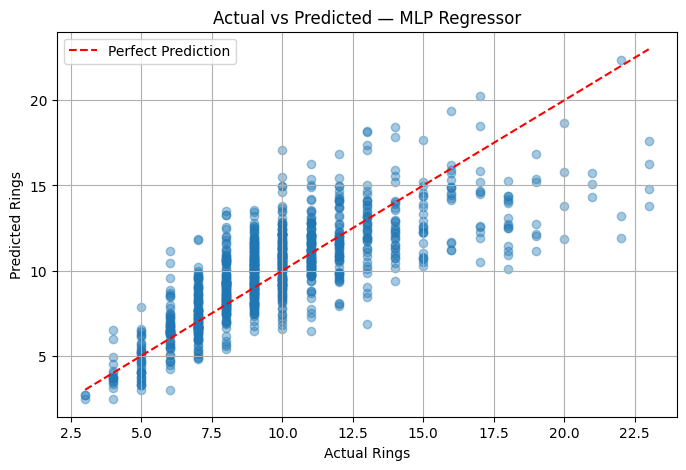

In [22]:
# Plot to understand how wrong/right the model is working
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted — MLP Regressor")
plt.legend()
plt.grid()
plt.show()

### Actual vs Predicted — Plot Analysis

Although Cross-Validation is an effective way to test the robustness of the model, there are other ways to understand how it works. This graph is an example of that, it allows you to visualize in a more user-friendly way where the model is right and where it is wrong, complementing the numerical metrics presented earlier.

The red line represents the correct prediction, so the closer the blue dot is to the line, the more accurate the prediction the further away, the more wrong.

---

**What the graph confirms:**

- For abalones with **few rings (3 to 12)**, the points are clustered close to the red line, indicating that the model predicts well in this range, which is consistent with the high concentration of data observed in the Rings distribution histogram, where most samples are between **8 and 11 rings**.

- For abalones with **more rings (15+)**, the points begin to move away from the line, with the model consistently **underestimating** the true values. This confirms what was anticipated during the EDA. The positive skewness of the Rings distribution means that there are very few training examples for older abalones, making it difficult for the model to learn in these cases.

- Overall, the graph is consistent with the **R² of 0.5685** the model captures the general trend well, but struggles at the extremes, particularly for high ring values where data is scarce.

## Implementing Ridge and Lasso Regression

In [23]:
from sklearn.linear_model import LinearRegression      # Ordinary Least Squares regression
from sklearn.linear_model import Ridge                 # Ridge regression (L2 regularisation)
from sklearn.linear_model import Lasso                 # Lasso regression (L1 regularisation)

In [24]:
# Calculate the model coefficients to understand the influence of each feature
# Train the model
lr_model = LinearRegression().fit(X_train, y_train)

# Calculate the train values
y_pred_train = lr_model.predict(X_train)

# Calculate the predicted values
y_pred_lr = lr_model.predict(X_test)

In [25]:
# Evaluate the model performance using test data

# y_test : actual/true values
# y_pred_lr : predicted values from the Linear Regression model


# Calculate Mean Squared Error (MSE)
# MSE measures the average squared difference between predicted and actual values.
# A lower MSE indicates a better fit.
mse_train_lr = mean_squared_error(y_train, y_pred_train)       # Train MSE
mse_lr = mean_squared_error(y_test, y_pred_lr)                 # Test MSE


# Calculate R-squared Score (R²)
# R² explains the proportion of variance in the target variable
# R² ranges from 0 to 1; higher values indicate a better model.
r2_train_lr = r2_score(y_train, y_pred_train)                  # Train R2
r2_lr = r2_score(y_test, y_pred_lr)                            # Test R2

# Print the results with formatting to 2 decimal places
# Train values
print("--Train values--")
print(f"Mean Squared Error (MSE): {mse_train_lr:.2f}")
print(f"R-squared Score (R²): {r2_train_lr:.2f}")

# Predict values
print("\n--Predict values--")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"R-squared Score (R²): {r2_lr:.2f}")

--Train values--
Mean Squared Error (MSE): 4.94
R-squared Score (R²): 0.53

--Predict values--
Mean Squared Error (MSE): 4.83
R-squared Score (R²): 0.53


As we've already explained what each metric represents, let's analyze the values:

- **MSE** — 4.83
- **R²** — 0.53

These results were obtained by applying Linear Regression, without applying the **L1 (Lasso)** and **L2 (Ridge)** regularizations.

---

### What is the importance of regularizations?

- As you can see, the training and test values are very close, showing that the problem of poor performance is not caused by overfitting. However, if we remember the heatmap showing the correlation of the features, we see that **multicollinearity** (many features with high correlation, which makes it difficult for the model to understand the importance of each one) is a problem for this model; therefore, regularization can solve the problem.

- A penalty is applied to the loss function so that the bias (the direction the model is predicting) and the variance (error without a specific pattern) come into equilibrium.


### What is Lasso?
- The Lasso model automatically selects features, so the less important a feature is, the closer the coefficient is to 0. 

- It's simpler and easier to interpret precisely because it often sets the coefficients of features that don't contribute to the prediction to zero. We could say it's a more "radical" model.

- It's very useful when there are many features with low coefficients.

  
### What is Ridge?
- Although the coefficients approach 0, it never reaches zero, unlike Lasso. 

- We can say that it is less radical, as it reduces the coefficients subtly. It is more advisable to use when there is a problem of multicollinearity — which is the case here.

In [26]:
# Initialize GridSearchCV + Cross Validation

# Lasso
param_grid_lasso = {
    "alpha": [0.001, 0.01, 0.1, 1.0, 10.0]   # regularisation strength
}

grid_lasso = GridSearchCV(
    estimator=Lasso(),
    param_grid=param_grid_lasso,                              # Hyperparameter combinations to evaluate
    cv=KFold(n_splits=5, shuffle=True, random_state=42),      # 5-fold cross-validation
    scoring="neg_mean_squared_error",                         # Use MSE to select best model
    verbose=1                                                 # Display the progress of the process
)

# The wrapped neural network model
param_grid = param_grid,                                 # Hyperparameter combinations to evaluate
cv = KFold(n_splits=5, shuffle=True, random_state=42),   # 5-fold cross-validation
scoring = "neg_mean_squared_error",                      # Use MSE to select best model
verbose = 1                                              # Display the progress of the process

grid_lasso.fit(X_train, y_train)


# Ridge
param_grid_ridge = {
    "alpha": [0.001, 0.01, 0.1, 1.0, 10.0]  # regularisation strength
}

grid_ridge = GridSearchCV(
    estimator = Ridge(),
    param_grid = param_grid_ridge,                           # Hyperparameter combinations to evaluate
    cv = KFold(n_splits=5, shuffle=True, random_state=42),   # 5-fold cross-validation
    scoring = "neg_mean_squared_error",                      # Use MSE to select best model
    verbose = 1                                              # Display the progress of the process
)

grid_ridge.fit(X_train, y_train)

print("\n Lasso")
print("Best Lasso parameters:", grid_lasso.best_params_)
print("Best MSE Lasso:", round(-grid_lasso.best_score_, 4))
print("\n Ridge")
print("\nBest Ridge parameters:", grid_ridge.best_params_)
print("Best MSE Ridge:", round(-grid_ridge.best_score_, 4))

# Regularisation strengths (hyperparameters) 
alpha_lasso = grid_lasso.best_params_["alpha"]     # Store the best alpha to Lasso
alpha_ridge = grid_ridge.best_params_["alpha"]     # Store the best alpha to Ridge

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits

 Lasso
Best Lasso parameters: {'alpha': 0.001}
Best MSE Lasso: 5.2125

 Ridge

Best Ridge parameters: {'alpha': 1.0}
Best MSE Ridge: 5.2151


In [27]:
from sklearn.pipeline import Pipeline                  # Combine preprocessing and models

# Define models using pipelines (regression)
models = {
    "Linear": Pipeline([
        ("model", LinearRegression())               # Ordinary Least Squares regression
    ]),
    "Ridge": Pipeline([
        ("model", Ridge(alpha = alpha_ridge))       # Ridge regression (L2 penalty)
    ]),
    "Lasso": Pipeline([
        ("model", Lasso(
            alpha=alpha_lasso,                      # L1 regularisation strength
            max_iter = 20000                        # Increase iterations to ensure convergence
        ))
    ]),
}

# Remember that the Standardscaler has already been applied to the data.

In [28]:
# Evaluation the models

results = {}   # Dictionary to store model results

print("\n Test Performance (MSE, R²) ")   # Header for output

# Loop through each model (Linear, Ridge, Lasso)
for name, pipe in models.items():
    pipe.fit(X_train, y_train)                               # Train model on training data
    preds = pipe.predict(X_test)                             # Predict target values for test data

    # Store evaluation metrics and model parameters
    results[name] = {
        "mse": mean_squared_error(y_test, preds),            # Mean Squared Error
        "r2": r2_score(y_test, preds),                       # R-squared score
        "coefficients": pipe.named_steps["model"].coef_,     # Model coefficients
        "intercept": pipe.named_steps["model"].intercept_    # Model intercept
    }

    # Print performance results for each model
    print(
        f"{name:6s} | "
        f"MSE = {results[name]['mse']:.4f} | "
        f"R² = {results[name]['r2']:.4f}"
    )


 Test Performance (MSE, R²) 
Linear | MSE = 4.8336 | R² = 0.5301
Ridge  | MSE = 4.8321 | R² = 0.5303
Lasso  | MSE = 4.8330 | R² = 0.5302


## Interpreting the Result

- As expected, applying regularization resulted in a slight improvement.

- However, the inherent biological limitations of abalone—reflected in the data—suggest that the problem goes beyond multicollinearity.

- Even with regularization applied, the dataset itself imposes a limit that prevents the model from achieving satisfactory performance.

In [29]:
# Ensure the coefficient of each feature trained

# Ensure feature names correspond exactly to the columns used in training
feature_names = list(X.columns)

# Create a table of coefficients for each model
coef_table = pd.DataFrame({
    "feature": feature_names,                                     # Feature names
    "Linear": np.ravel(results["Linear"]["coefficients"]),        # Linear regression coefficients
    "Ridge":  np.ravel(results["Ridge"]["coefficients"]),         # Ridge regression coefficients (L2)
    "Lasso":  np.ravel(results["Lasso"]["coefficients"]),         # Lasso regression coefficients (L1)
})

# Sort features by absolute Linear coefficient (importance ranking)
coef_table["abs_linear"] = coef_table["Linear"].abs()
coef_table = (
    coef_table
    .sort_values("abs_linear", ascending=False)
    .drop(columns=["abs_linear"])
)

# Display coefficient table
print("\n Coefficients (sorted by |Linear|) ")
print(coef_table.to_string(index=False))

# Count how many coefficients Lasso shrinks to (near) zero
lasso_zeros = np.sum(np.isclose(coef_table["Lasso"].values, 0.0))
print(f"\nLasso set {lasso_zeros} out of {len(feature_names)} coefficients to (near) zero.")


 Coefficients (sorted by |Linear|) 
       feature    Linear     Ridge     Lasso
Shucked_weight -4.640313 -4.532740 -4.571092
  Whole_weight  4.416312  4.192547  4.259525
      Diameter  1.342627  1.326315  1.266384
  Shell_weight  1.319663  1.395104  1.369491
Viscera_weight -0.951781 -0.901628 -0.907799
        Height  0.471808  0.472987  0.470709
        Length -0.165781 -0.153392 -0.090183
           Sex  0.065050  0.064591  0.063647

Lasso set 0 out of 8 coefficients to (near) zero.


## Interpreting the coefficients

- **Shucked_weight** — Analyzing the absolute value (without the negative sign), it represents the most relevant feature. Although it may seem counterintuitive at first, there is an explanation. Imagine rings = life experience, and Shucked_weight = muscles. Older people tend to have more life experience (just as older abalones have more rings), however, older people tend to have less muscle than younger ones — therefore, older abalones have proportionally less meat than younger ones.

- **Sex** — As anticipated from the correlation heatmap, this feature has practically no influence on the prediction.

- **Length** — Although it might seem like an important feature — since one might assume that greater length means more rings — observing the coefficients, this feature had little influence on the model. However, if we observe the **Diameter** feature...

- **Diameter** — It showed a relevant coefficient, confirming that it is an important feature for the model. It is worth noting that the Diameter–Length correlation was **0.99**, meaning the models understood that if Diameter is used, Length becomes redundant. This also explains why **Length** shows a near-zero coefficient (**-0.17**) despite being intuitively relevant — the model effectively replaced it with **Diameter**.

- **Whole_weight** — The heavier the abalone, the more rings it tends to have, making this a positively influential feature for the prediction.

-------
Lasso set 0 out of 8 coefficients to (near) zero.
>Although Lasso tends to zero out features considered irrelevant to the model, some were quite low, but none were completely eliminated.

<Figure size 640x480 with 0 Axes>

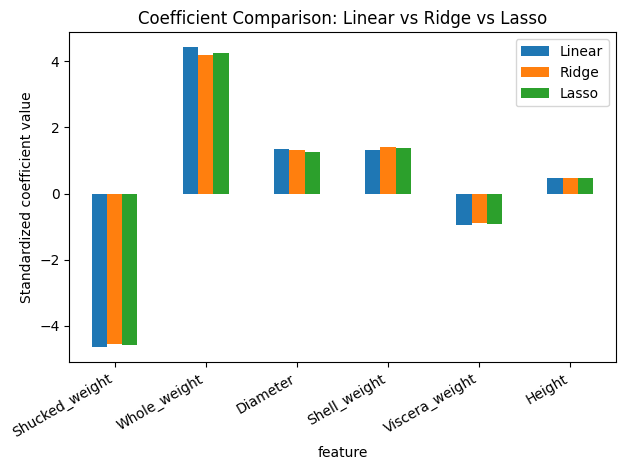


Try changing alpha_ridge and alpha_lasso to show stronger/weaker regularization.


In [30]:
# Plotting the above information in a way that is easier to visualize.

# Select top features for visualisation (limit to 6 for readability)
top_k = min(6, len(feature_names))     # Ensure we do not exceed available features

# Prepare data for plotting (use most important features)
plot_df = coef_table.head(top_k).set_index("feature")

# Create bar plot to compare coefficients across models
plt.figure()                                                         # Create a new figure
plot_df.plot(kind="bar")                                             # Bar chart of coefficients
plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")        # Plot title
plt.ylabel("Standardized coefficient value")                         # Y-axis label
plt.xticks(rotation=30, ha="right")                                  # Rotate feature labels for readability
plt.tight_layout()                                                   # Adjust layout to prevent overlap
plt.show()                                                           # Display the plot

# Encourage experimentation with regularisation strength
print("\nTry changing alpha_ridge and alpha_lasso to show stronger/weaker regularization.")

## **Observation:**
- The regression results are similar, but the difference in the coefficients is visible, a result of the regularizations performed by the respective models. 

- The other characteristics have already been explained above—here we see only the graphical confirmation of them.

## Comparison between the models
| Model | MSE | R² |
|---|---|---|
| **MLP Regressor** | 4.4348 | 0.5685 |
| **Linear Regression** | 4.8336 | 0.5301 |
| **Ridge** | 4.8321 | 0.5303 |
| **Lasso** | 4.8330 | 0.5302 |

## Conclusion

- In this analysis, we obtained the following model results: **MLP Regressor**, **Ridge**, and **Lasso**.

- The model that showed the best performance was the **MLP Regressor**, which obtained **R² = 0.5685**.

- Knowing that there is a multicollinearity problem in the dataset, and using **Ridge** and **Lasso**, there was no better performance compared to the **MLP Regressor** — there was a slight improvement compared to **Linear Regression**, but it became clear that the model's poor performance is not solely due to multicollinearity.

---

### Main Conclusions

- One factor that stood out was that, when using Grid Search, the alpha result obtained was **`alpha: 0.001`** — this shows that even if a higher alpha value were used, i.e., stronger regularization, it would not benefit the model.

- Although **Sex** and **Length** showed very low influence, **Shucked_weight** and **Whole_weight** were the most influential features. Some of this information was already predicted during the EDA.

---

### Positive Points

- In predictions between **3 and 12 rings**, the **MLP Regressor** performed well, showing that at least part of the non-linear pattern of the dataset was understood by the algorithm. Meanwhile...

---

### Negative Points

- Despite this, we did not obtain a performance greater than **0.57**.

- This can be explained by the following factors:

    - Even though models that handle **high multicollinearity** well were used, this remains a factor that makes the dataset complex.

    - The statistical summary showed that in up to **75% of the samples**, 11 rings was the median, while the maximum value was **29 rings**. This raises the question — would the model perform better if there were a larger sample of older abalones with a greater number of rings?

    - Finally, in almost all features, when plotting the data distribution, we observe **positive skewness** in almost all of them — that is, in fact, there is a lack of data from older abalones to make it possible to reduce the tail and, consequently, the complexity of the dataset.

# TASK 2

In [31]:
# Load the data
df_2 = pd.read_csv("yelp.csv", encoding = "latin-1")

df_2.head()

,Unnamed: 0,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


#### Why are all the preprocessing steps necessary?

- Imagine someone hands you a text written in a language you don't understand. The words are there, the paper exists, the information exists but if you don't read that language, it means nothing to you. It's not because the information is bad, it's because it's in a format you can't yet process.

- The same thing happens with a computer.

- When I load the Yelp.csv file, there are hundreds of reviews written by people, but these reviews contain slang, punctuation, typos, emojis, stopwords like "the," "a," and "is."

- For a human, when we understand the context, it's easy to ignore this noise (any additional information that hinders understanding the message).

- For the computer, all of this is just text, without meaning.

- Therefore, before any analysis, it's necessary to translate not from one language to another, but from human text to a form that the machine can interpret.

In [32]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   10000 non-null  int64
 1   business_id  10000 non-null  str  
 2   date         10000 non-null  str  
 3   review_id    10000 non-null  str  
 4   stars        10000 non-null  int64
 5   text         10000 non-null  str  
 6   type         10000 non-null  str  
 7   user_id      10000 non-null  str  
 8   cool         10000 non-null  int64
 9   useful       10000 non-null  int64
 10  funny        10000 non-null  int64
dtypes: int64(5), str(6)
memory usage: 8.4 MB


In [33]:
# Checking null values
df_2.isnull().sum()

Unnamed: 0     0
business_id    0
date           0
review_id      0
stars          0
text           0
type           0
user_id        0
cool           0
useful         0
funny          0
dtype: int64

In [34]:
# Common mappings:
# - label column: "sentiment" (0 = negative, 1 = neutral, 2 = positive)
# - text column:  "text"
y = "sentiment"
X  = "text"

In [35]:
# Apply a function to convert the feature start into a new feature sentiment
def convert_stars_to_sentiment(stars):
    if stars <= 2:
        return 0    # negative
    elif stars == 3:
        return 1    # neutral
    else:
        return 2    # positive

df_2["sentiment"] = df_2["stars"].apply(convert_stars_to_sentiment)

In [36]:
# Checking if it worked
df_2.head()

,Unnamed: 0,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny,sentiment
0,0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0,2
1,1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0,2
2,2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0,2
3,3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0,2
4,4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0,2


In [37]:
# To improve the visualization
df_2[["text", "sentiment"]]

,text,sentiment
0,My wife took me here on my birthday for breakf...,2
1,I have no idea why some people give bad review...,2
2,love the gyro plate. Rice is so good and I als...,2
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",2
4,General Manager Scott Petello is a good egg!!!...,2
...,...,...
9995,First visit...Had lunch here today - used my G...,1
9996,Should be called house of deliciousness!\n\nI ...,2
9997,I recently visited Olive and Ivy for business ...,2
9998,My nephew just moved to Scottsdale recently so...,0


## Understanding sentiment and other correlated features

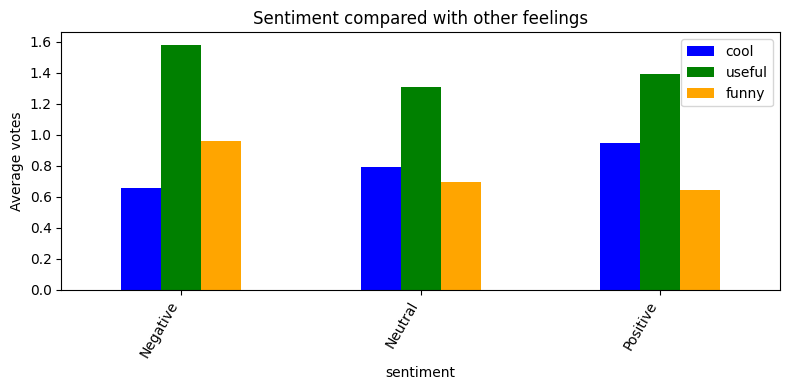

In [38]:
## Plot sentiment x review evaluation
df_2.groupby("sentiment")[["cool", "useful", "funny"]].mean().plot(                      # Group the features that gonna be used on the plot
    kind="bar", figsize=(8, 4), color=["blue", "green", "orange"]
)
plt.title("Sentiment compared with other feelings")                                      # Add chart title
plt.xticks([0, 1, 2], ["Negative", "Neutral", "Positive"], ha = "right", rotation=60)    # Rotate x-axis labels for better readability
plt.ylabel("Average votes")                                                              # Add a name for y label
plt.tight_layout()                                                                       # Adjust layout to prevent label overlap
plt.show()                                                                               # Display the plot

### Observing this plot:

- It's clear that the most decisive vote for the final decision is the **cool** feature. While in positive reviews this value reached almost 1, in negative reviews it didn't exceed 0.65. This means the comment was interesting and likely a well-rated **cool** comment tends to influence people more easily.

- The **funny** feature, despite seeming positive, showed that the more 'funny' was voted on, the lower the final score became. This means that the negative experiences shared by the customer generated some laughs among the rest of the community.

- The **useful** feature doesn't seem to follow a pattern, as whether the comment is good or bad, it can be useful in both ways.

- Analyzing the **neutral** review, it's the most balanced, illustrating a person who couldn't decide whether to approve or not, and a community that, based on that review, didn't reach a conclusion.

In [39]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   10000 non-null  int64
 1   business_id  10000 non-null  str  
 2   date         10000 non-null  str  
 3   review_id    10000 non-null  str  
 4   stars        10000 non-null  int64
 5   text         10000 non-null  str  
 6   type         10000 non-null  str  
 7   user_id      10000 non-null  str  
 8   cool         10000 non-null  int64
 9   useful       10000 non-null  int64
 10  funny        10000 non-null  int64
 11  sentiment    10000 non-null  int64
dtypes: int64(6), str(6)
memory usage: 8.5 MB


## Split the data into Train & Test

In [40]:
# Define the new DataFrame with the features that will be used
df_yelp = df_2[["text", "sentiment"]]

In [41]:
# Sentiment Analysis on Yelp review Dataset (Train/Test like Yelp Dataset)
import pandas as pd                                                       # Import pandas for working with DataFrames
from sklearn.model_selection import train_test_split                      # Import function to split dataset into train/test

y_col = "sentiment"                                                       ## Label column name (0 = negative, 1 = neutral , 2 = positive)
X_col = "text"                                                            # Text column name (yelp review content)

# Split into train and test sets into df
train_df, test_df = train_test_split(                                     # Create training and testing DataFrames
    df_yelp,                                                              # Dataset with 2 features
    test_size = 0.2,                                                      # 20% for test set
    random_state = 42,                                                    # Reproducible split
    stratify = df_yelp[y_col]                                             # Preserve label proportions in both splits
)

train_df = train_df.rename(columns = {X_col: "text", y_col: "label"})     # Rename columns to match TweetEval style
test_df  = test_df.rename(columns = {X_col: "text", y_col: "label"})      # Rename columns to match TweetEval style

train_df = train_df.reset_index(drop = True)                              # Reset index for clean DataFrame
test_df  = test_df.reset_index(drop = True)                               # Reset index for clean DataFrame

print(train_df.head())                                                    # Display first 5 rows of the training dataset
print(train_df["label"].value_counts())                                   # Show class distribution in training set

                                                text  label
0  Tacos, tacos, tacos......how can something so ...      2
1  This was my second time dining at this Benihan...      2
2  The facility is a bit dated, but the service i...      2
3  What a beautiful hotel! The Clarendon is truly...      2
4  What's up with the premium gas in this state b...      0
label
2    5490
0    1341
1    1169
Name: count, dtype: int64


## Next Step

### The important features for training and testing the model were included in df_yelp, where:

- **X = text**

- **y = sentiment**

- Note the imbalance between the classes:

| Sentiment | Total | legend |
|---|---|---|
| **2**  | **5490** | **(Positive)** |
| **1**  | **1169** | **(Neutral)** |
| **0** | **1341** | **(Negative)** |

- The stratify parameter ensures that these proportions are preserved in both training and testing — preventing the model from giving less importance to a class with less weight.

With training and test defined, we will proceed to the **next step**...

## Text Preprocessing (NLP Pipeline)

As explained with the language analogy, after better understanding the dataset and performing all the necessary text preprocessing steps, we will now begin to transform it into a *"language that the computer understands"*, that is, process it so that the model reads correctly and trains the data.

As also mentioned before, there is a lot of noise in this data, namely:

---

**🔡 Lower/Upper case**

Each user wrote it in a different way, for example, the word *restaurant* can be written: *RESTAURANT*, *Restaurant*, *RESTAURant*, or even with some error. Therefore, it is important to ensure that all words are in lowercase.

--

**🔗 Links (URLs) and mentions**
These are also noise for the computer, so it's important to keep the text as clean as possible, so that everything in it will be used to train and test the model.

--

**🔢 Numbers and special characters**
While punctuation has its function in grammar, besides many people using it incorrectly, the computer also doesn't understand it, so it should be removed as well.

--

**Extra spaces**
Having extra spaces in the text only hinders the model's performance, in addition to requiring more memory and processor resources.

--

**🔤 Tokenization**
The model will divide each word within the sentence, considering that it's not possible to analyze the sentence as a whole. Thanks to this process, it's possible to discover the most used words and understand which keywords help define which of the 3 possible results the review was classified in.

--

**🚫 Stopword Removal**
That is, words that add nothing, as they appear in all reviews and do not contribute useful patterns to the model.

--

**📝 Lemmatization**
Some words, despite being different, refer to the same thing — for example: *eat*, *ate*, *eaten*. The idea is the same, so it is important to identify the base form of the word and ensure that variations of the same word do not disrupt the model.

In [42]:
import re                                                                   # Regular expressions for text cleaning
import nltk                                                                 # Natural Language Toolkit library
from nltk.corpus import stopwords                                           # Import stopwords list
from nltk.stem import WordNetLemmatizer                                     # Import lemmatizer

nltk.download("stopwords")                                                  # Download English stopwords (run once)
nltk.download("wordnet")                                                    # Download WordNet dictionary (run once)
nltk.download("omw-1.4")                                                    # Download multilingual WordNet data (run once)

STOPWORDS = set(stopwords.words("english"))                                 # Store English stopwords in a set (faster lookup)
lemmatizer = WordNetLemmatizer()                                            # Create lemmatizer object

def preprocess_text(text: str) -> str:                                      # Function takes text and returns cleaned text
    text = text.lower()                                                     # Convert text to lowercase
    text = re.sub(r"http\S+|www\S+", " ", text)                             # Remove URLs
    text = re.sub(r"@\w+", " ", text)                                       # Remove mentions (@username) from reviews
    text = re.sub(r"#", " ", text)                                          # Remove hashtag symbol only (keep the word)
    text = re.sub(r"[^a-z\s]", " ", text)                                   # Remove numbers and special characters (keep letters & spaces)
    text = re.sub(r"\s+", " ", text).strip()                                # Remove extra spaces    
    tokens = text.split()                                                   # Split text into individual words
    tokens = [lemmatizer.lemmatize(t)                                       # Lemmatize each word (convert to base form)
              for t in tokens                                               # Loop through each token
              if t not in STOPWORDS                                         # Remove stopwords
              and len(t) > 1]                                               # Remove very short words (length <= 1)

    return " ".join(tokens)                                                 # Join cleaned tokens back into a single string

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lucas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lucas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\lucas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Display the before and after

- Here we can see some examples. The samples shown do not contain numbers, stopwords, capital letters, punctuation, etc. Only the words that will actually be interpreted by the machine.
Continuing the analogy: imagine a language you don't know and you've been given that piece of paper — now it's as if someone gave you the translation.

In [43]:
# Apply this function into a sample so is possible to compare the results
sample = train_df.sample(20, random_state = 42)[["text", "label"]].copy()     # Randomly select 20 rows (fixed seed for reproducibility) and keep only 'text' and 'label' columns
sample["clean_text"] = sample["text"].apply(preprocess_text)                 # Apply preprocessing function to the 'text' column and store results in a new column called 'clean_text'

sample                                                                       # Display the sampled DataFrame with original text, label, and cleaned text

,text,label,clean_text
2215,Finding this quaint location wasn't to hard......,1,finding quaint location hard like parking lot ...
2582,Outstanding customer service!!! Great camping ...,2,outstanding customer service great camping fir...
1662,Great location and within walking distance to ...,2,great location within walking distance scottsd...
3027,I'd read about this place before (on blogs wri...,1,read place blog written people utah driving ba...
4343,Soooo this location is even better than the on...,2,soooo location even better one superstition sp...
2680,On atmosphere alone I'd give Sapporo five star...,1,atmosphere alone give sapporo five star restau...
1765,Great place for shows. Excellent place for eve...,2,great place show excellent place everyone
1123,A friend was visiting from out of town and we ...,0,friend visiting town decided wanted pampering ...
4054,Good salad options. It is definitely tough to ...,1,good salad option definitely tough mess lettuc...
3761,one of my favorite places ! the place has gr...,2,one favorite place place great atmosphere char...


## Compute & visualise basic text statistics (token frequency)

Now that the text has been cleaned and processed, we can extract interesting observations and insights from it. Using visualisations makes it easier to interpret what the data is telling us.

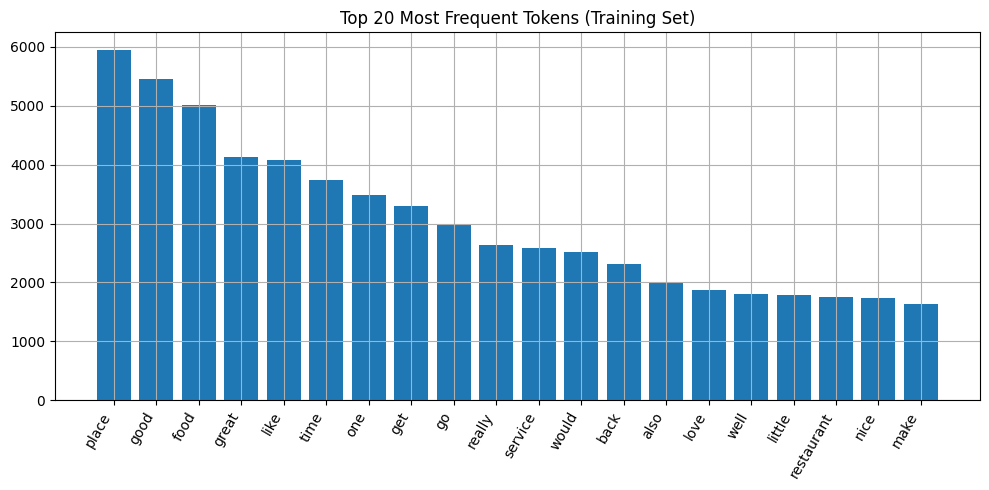

In [44]:
from collections import Counter                                         # Import Counter to count word frequencies
import matplotlib.pyplot as plt                                         # Import matplotlib for visualization

train_df["clean_text"] = train_df["text"].apply(preprocess_text)        # Apply preprocessing to all training tweets
all_tokens = " ".join(train_df["clean_text"]).split()                   # Combine all cleaned text into one string and split into individual tokens

token_counts = Counter(all_tokens)                                      # Count frequency of each token
top_n = 20                                                              # Number of top frequent words to display

most_common = token_counts.most_common(top_n)                           # Get the top 20 most common words and their counts
words, freqs = zip(*most_common)                                        # Separate words and frequencies into two lists
plt.figure(figsize = (10, 5))                                           # Create a figure with specified size
plt.bar(words, freqs)                                                   # Create a bar chart of word frequencies
plt.xticks(rotation = 60, ha = "right")                                 # Rotate x-axis labels for better readability
plt.title(f"Top {top_n} Most Frequent Tokens (Training Set)")           # Add chart title
plt.tight_layout()                                                      # Adjust layout to prevent label overlap
plt.grid()
plt.show()                                                              # Display the plot

### Plot Analysis

As indicated by the graph, these are the 20 most frequent words in the reviews — from 'place' with almost 6000 occurrences, to 'make' with around 1700. This confirms that only relevant words were retained for training, and the **absence of stopwords** such as 'the', 'is', or 'and' confirms that the preprocessing worked as expected.

## Sentiment analysis using VADER (rule-based)

In [45]:
from nltk.sentiment import SentimentIntensityAnalyzer                # Import VADER sentiment analyzer from NLTK

nltk.download("vader_lexicon")                                       # Download VADER sentiment lexicon (run once)
sia = SentimentIntensityAnalyzer()                                   # Create VADER analyzer object

def vader_label(text: str) -> int:                                   # Function takes text and returns sentiment label (0, 1, 2)
    scores = sia.polarity_scores(text)                               # Get sentiment scores (neg, neu, pos, compound)
    c = scores["compound"]                                           # Extract compound score (overall sentiment score)
    if c >= 0.05:                                                    # If compound score is strongly positive
        return 2                                                     # Return 2 -> positive
    elif c <= -0.05:                                                 # If compound score is strongly negative
        return 0                                                     # Return 0 -> negative
    else:                                                            # Otherwise (between -0.05 and 0.05)
        return 1                                                     # Return 1 -> neutral

test_df["vader_pred"] = test_df["text"].apply(vader_label)           # Apply VADER function to test tweets and store predictions
print(test_df[["text", "label", "vader_pred"]].head(10))             # Display first 10 rows with original label and VADER prediction

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\lucas\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                text  label  vader_pred
0  NOCA...  wow.\n\nHave you seen the outer limit...      2           2
1  The main reason for the four stars is for thei...      2           2
2  Can someone please tell me why people go here?...      0           0
3  Had some time to kill before the Ultimate pleY...      0           2
4  Went here earlier this spring and WOW - What a...      2           2
5  ok....first let me say that I grew up in PHX. ...      1           2
6  I just don't think I'm much of a brewery gal. ...      1           2
7  Ok....my 2nd review of an "Irish" pub.  And we...      2           2
8  I don't usually review based on one visit.  Bu...      0           0
9  This is a great place to take your time and en...      2           2


In [46]:
# Get the accuracy
accuracy = (test_df["label"] == test_df["vader_pred"]).mean()                  # Boolean comparison -> True = 1, False = 0
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.7305


### Vader Analysis

- Before training the dataset using machine learning models, VADER (Valence Aware Dictionary and sEntiment Reasoner) was used as a starting point.

- Despite the **good accuracy of 0.7305**, it is important to highlight that the model did not see any Yelp data. VADER works with its own internal dictionary, where each word already has an associated sentiment score.

- Based on the values defined in the vader_label function, it classifies each review based on the compound score — if the value is ≥ 0.05, it is positive; if it is ≤ -0.05, it is negative; otherwise, it is neutral.

- 73% accuracy without seeing any Yelp data is a thought-provoking result. And the token graph helps explain why — the most used words in the reviews are extremely expressive: 'good', 'great', 'love', 'nice'. These are words that anyone — or any dictionary — immediately recognizes as positive. Ultimately, when someone writes a review on Yelp, they rarely sit on the fence. They either loved it or hated it — and the words you choose reflect that.

- However, it offers several advantages that make it a very useful tool for sentiment analysis. Because it requires no training, the processing time is reduced, and because it understands intensified words (positive or negative) very well, it becomes a very useful tool for short, informal texts originating from social networks.

- The drawback arises when the language ceases to be obvious. VADER doesn't understand context—it doesn't perceive irony, sarcasm, or mixed phrases such as 'The service was excellent, but the food was terrible.' For it, each word stands on its own. This explains the poor performance of Neutral; a 3-star review rarely uses clearly positive or negative words, and the dictionary simply doesn't know where to place them.

In [47]:
from sklearn.metrics import classification_report

print(classification_report(
    test_df["label"],
    test_df["vader_pred"],
    target_names=["Negative", "Neutral", "Positive"],
    digits=4
))

              precision    recall  f1-score   support

    Negative     0.6813    0.3701    0.4797       335
     Neutral     0.2258    0.0240    0.0433       292
    Positive     0.7443    0.9687    0.8418      1373

    accuracy                         0.7305      2000
   macro avg     0.5505    0.4543    0.4549      2000
weighted avg     0.6580    0.7305    0.6646      2000



### Classification Report Analysis

- **Precision** - When the model predicts a class, how accurate is it?

- **Recall** - Of all the examples of the class in question, how many were found?

- **F1-score** - Harmonic mean between precision and recall

- **Support** - Number of samples

---
#### Class 2 (Positive)
- Recall of 0.9687 shows that almost all positive reviews were correctly identified. Conversely, the precision has already dropped to 0.7543, indicating that the model tends to classify reviews that are not positive as such. Even so, the F1 score of 0.8418 confirms the model's good performance.

#### Class 1 (Neutral)
- Precision of 0.2258 and recall of 0.0240, with a very low F1-score of 0.0433. The model has great difficulty identifying a neutral review, which completes one of the problems mentioned above; of the many neutral reviews that exist, most of them were classified as positive.

### Class 0 (Negative):

- Precision of 0.68, a decent value, but the recall of 0.3701 detects, on average, about 37 out of every 100 negative comments. The F1-score value of 0.47 reflects the performance of the model.

## Transform text using Bag of Words + ML classification model

In [48]:
from sklearn.model_selection import train_test_split                     # Import function to split dataset (not used here but commonly used)
from sklearn.feature_extraction.text import CountVectorizer              # Import CountVectorizer for Bag-of-Words
from sklearn.linear_model import LogisticRegression                      # Import Logistic Regression classifier
from sklearn.pipeline import Pipeline                                    # Import Pipeline to combine steps
from sklearn.metrics import classification_report, confusion_matrix      # Import evaluation metrics

X_train = train_df["clean_text"]                                         # Training features (preprocessed text)
y_train = train_df["label"]                                              # Training labels (sentiment classes)

X_test = test_df["text"].apply(preprocess_text)                          # Preprocess test text using the same function
y_test = test_df["label"]                                                # True labels for test data

model = Pipeline([                                                       # Create ML pipeline
    ("bow", CountVectorizer(ngram_range = (1, 2), min_df = 2)),          # Convert text to Bag-of-Words features (unigrams + bigrams, ignore rare words)
    ("clf", LogisticRegression(max_iter = 1000))                         # Apply Logistic Regression classifier
])

model.fit(X_train, y_train)                                              # Train the model on training data

pred = model.predict(X_test)                                             # Generate predictions on test data

bow_pred = pred                                                          # Store pred value in bow_pred

print(classification_report(y_test, pred, digits=4))                     # Print precision, recall, F1-score, and accuracy

print("Confusion matrix:\n", confusion_matrix(y_test, pred))             # Display confusion matrix

              precision    recall  f1-score   support

           0     0.7168    0.6119    0.6602       335
           1     0.4255    0.2740    0.3333       292
           2     0.8388    0.9323    0.8831      1373

    accuracy                         0.7825      2000
   macro avg     0.6604    0.6061    0.6255      2000
weighted avg     0.7580    0.7825    0.7655      2000

Confusion matrix:
 [[ 205   49   81]
 [  47   80  165]
 [  34   59 1280]]


Using Bag of Words, the accuracy was even better **0.7825**, but before commenting further on this, it's important to understand what was done.

## Why use Bag of Words?

We saw that by analyzing word by word, the model achieved good performance; however, some words, when followed by others, can have a different meaning or even intensify the comment. Therefore, using the parameter **ngram_range = (1, 2)**, we tell the model that each word should be analyzed individually, and the word in question plus the word next to it. So, taking a real example from the dataset:

**Can someone please tell me why people go here?**

The model will try:

    - Can 
    - someone 
    - please 
    - tell etc..

BUT it will also try:

    - Can someone 
    - someone please 
    - please tell etc..
---
#### Complementing this discussion, there is also the parameter **min_df = 2**

Here, the value passed is the value at which a word that does not appear in the document at least this many times should be discarded. This is important because in a dataset with 10,000 rows, if a word appears only once, it is very rare or very irrelevant. And aiming to improve the model's performance, this is a way to reduce noise (anything that hinders the understanding of the message).

With the help of these parameters, we arrive at an accuracy of **0.7825**.

---
### Confusion Matrix
Analyzing the matrix, we note:

- Class 2 (positive) performed excellently, with many correct predictions.

- Class 1 (neutral) performed very poorly; it is noticeable that most of the time it classified a neutral comment as positive. The model clearly has difficulty with this classification.

- In class 0 (negative), the performance was good. Despite being confused with the positive classification in many predictions, it maintained good performance.

Several factors may explain this:

- As seen above, the number of samples between classes is unbalanced (even using the parameter `class_weight="balanced"`, the accuracy decreased).

- The Bag of Words model failed to learn the pattern of the Neutral class, hence the poor performance.

---
### Classification Report
- **Precision** - When the model predicts a class, how accurate is it?

- **Recall** - Of all the examples of the class in question, how many were found?

- **F1-score** - Harmonic mean between precision and recall

- **Support** - Number of samples

The Classification Report reinforces and makes it easier to interpret what was seen and explained in the matrix:

### In class 2 (positive):

- Both precision and recall are high, with the F1-score also having a high value. This shows that the class is often predicted correctly.

### In class 1 (neutral):

- Low values ​​are found in all metrics, which confirms the great difficulty the system has in predicting this class correctly.

### In class 0 (negative):

- Decent performance, but still low compared to class 2.

In summary, basically everything explained in the matrix now becomes more visual and understandable.

It's important to highlight the weighted average value; we see it's around 76%, and this difference from 100% is explained by the difference in distribution. When we see the support for 1 = 292, while the support for 2 = 1373, this justifies this value.

Taking all this into consideration, I obtained an **accuracy of 0.7825**.

## Transform text using TF-IDF + ML classification model

In [49]:
from sklearn.model_selection import train_test_split                     # Import function to split dataset (not used here but commonly used)
from sklearn.feature_extraction.text import TfidfVectorizer              # Import TF-IDF vectorizer (use CountVectorizer for Bag-of-Words)
from sklearn.linear_model import LogisticRegression                      # Import Logistic Regression classifier
from sklearn.pipeline import Pipeline                                    # Import Pipeline to combine steps
from sklearn.metrics import classification_report, confusion_matrix      # Import evaluation metrics

X_train = train_df["clean_text"]                                         # Training features (preprocessed text)
y_train = train_df["label"]                                              # Training labels (sentiment classes)

X_test = test_df["text"].apply(preprocess_text)                          # Preprocess test text using the same function
y_test = test_df["label"]                                                # True labels for test data

model = Pipeline([                                                       # Create ML pipeline
    ("tfidf", TfidfVectorizer(ngram_range = (1, 2), min_df = 2)),        # Convert text to TF-IDF features (unigrams + bigrams, ignore rare words)
    ("clf", LogisticRegression(max_iter = 1000))                         # Apply Logistic Regression classifier (increase iterations for convergence)
])

model.fit(X_train, y_train)                                              # Train the model on training data
pred = model.predict(X_test)                                             # Generate predictions on test data

tfidf_pred = pred                                                        # Store pred into tfidf_pred

print(classification_report(y_test, pred, digits = 4))                   # Print precision, recall, F1-score, and accuracy

print("Confusion matrix:\n", confusion_matrix(y_test, pred))             # Display confusion matrix

              precision    recall  f1-score   support

           0     0.8482    0.4836    0.6160       335
           1     0.4909    0.0925    0.1556       292
           2     0.7731    0.9876    0.8673      1373

    accuracy                         0.7725      2000
   macro avg     0.7041    0.5212    0.5463      2000
weighted avg     0.7445    0.7725    0.7213      2000

Confusion matrix:
 [[ 162   16  157]
 [  24   27  241]
 [   5   12 1356]]


## Why use TF-IDF?

- Since Bag of Words didn't solve the problem, I tried another approach, using **TF-IDF (Term Frequency-Inverse Document Frequency)**. This model **weights words so that very common words**, that is, words that appear frequently, are less relevant than words that appear less often. This allows the model to focus on words that are more informative.
- Following the same approach as before, we apply **ngram_range = (1, 2)** and **min_df = 2**, capturing both individual words and word combinations while filtering out rare terms. With these settings, the model achieved an accuracy of **0.7725**.

---

### Confusion Matrix
Analyzing the matrix, we note:

- Class 2 (positive) still performed very well, with most predictions correct.  

- Class 1 (neutral) performed poorly; most of the time, neutral comments were classified as positive. The model continues to have difficulty with this class.  

- Class 0 (negative) performance was decent; although some predictions were confused with positive, it maintained reasonable accuracy.

Factors that may explain this:

- The dataset is still unbalanced (support for class 1 = 292, class 2 = 1373).  
- TF-IDF did not fully solve the challenge of learning patterns for the neutral class, so performance for class 1 remains low.

---

### Classification Report
- **Precision** - When the model predicts a class, how accurate is it?  
- **Recall** - Of all the examples of the class in question, how many were found?  
- **F1-score** - Harmonic mean between precision and recall  
- **Support** - Number of samples  

The Classification Report reinforces and makes it easier to interpret what was seen and explained in the matrix:

### In class 2 (positive):

- Precision and recall remain high, with a strong F1-score. The class is frequently predicted correctly.

### In class 1 (neutral):

- All metrics are low, confirming the system's struggle to predict this class accurately.

### In class 0 (negative):

- Decent performance, but still lower than class 2.

In summary, everything explained in the matrix is now visualized clearly in the report.

It is important to highlight the **weighted average** value; it is around 72%, lower than Bag of Words. This difference from 100% is explained by the class imbalance and the difficulty in predicting class 1. The support values (class 1 = 292, class 2 = 1373) justify this result.

Taking all this into consideration, I obtained an **accuracy of 0.7725**.

## Comparison of Models

In [50]:
from sklearn.metrics import accuracy_score                                     # Import accuracy metric

acc_results = {                                                                # Store all accuracies in one place
    "VADER": accuracy_score(test_df["label"], test_df["vader_pred"]),          # Accuracy of VADER predictions
    "BoW + LR": accuracy_score(y_test, bow_pred),                              # Accuracy of CountVectorizer + Logistic Regression
    "TF-IDF + LR": accuracy_score(y_test, tfidf_pred)                          # Accuracy of TF-IDF + Logistic Regression
}

for k, v in sorted(acc_results.items(), key=lambda x: x[1], reverse=True):     # Sort accuracies from best to worst
    print(f"{k:10s} accuracy: {v:.4f}")                                        # Print each accuracy neatly

BoW + LR   accuracy: 0.7825
TF-IDF + LR accuracy: 0.7725
VADER      accuracy: 0.7305


### Analyzing the accuracies

| Model | Accuracy |
|---|---|
| **BoW + Logistic Regression** | **0.7825** |
| **TF-IDF + Logistic Regression** | 0.7725 |
| **VADER** | 0.7305 |

- The best performing model was **BoW + Logistic Regression**, with an accuracy of **0.7825**.

- **VADER**, despite never having seen the data, achieved **0.7305** — a surprisingly high accuracy, considering that the model does not train on the dataset, and which demonstrates how the language used in Yelp reviews tends to be expressive and direct.

- **TF-IDF** was slightly below BoW. Although TF-IDF is theoretically more sophisticated, penalizing very common words in favor of more informative words. In this case, the frequency-based approach of the Bag of words (BoW) proved more effective. This suggests that, in this dataset, the **presence** of a word matters more than its rarity.

- In all models, the difficulty in predicting **class 1 (neutral)** was present, consistently the most difficult due to the imbalance between classes and the ambiguous nature of neutral reviews.

# TASK 3

In [51]:
# Libraries importants to run the model
#!pip install transformers
#!pip install transformers torch accelerate sentencepiece
#!pip install tf-keras

In [52]:
import llmfunctions as LLM

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [53]:
import random                                                  # Used to randomly select text chunks or samples from the dataset
from pathlib import Path                                       # Helps handle file paths and check if files exist in a platform-independent way

from sklearn.feature_extraction.text import TfidfVectorizer    # Converts text documents into numerical TF-IDF vectors for similarity comparison
from sklearn.metrics.pairwise import cosine_similarity         # Calculates similarity between text vectors to retrieve relevant content
from transformers import pipeline                              # Loads pre-trained Hugging Face models to perform NLP tasks such as text generation

## Next Steps:

Before we finally create a model that extracts questions and answers from a long text, there are a series of steps that must be followed:
- Load the text from a book about banks
- Clean the text, transforming the raw text into clean text (URLs, links, uppercase and lowercase letters combined, spaces)
- Divide this clean text into chunks, that is, divide it into pieces, so that the model can understand and run the model appropriately.
- Although the chunks make things a little easier, there is still a lot of text and data, so it is important for the model to understand which parts are relevant to the final objective (generating questions and answers)
- Create prompts that return summaries to give us an overview of the model
- Generate questions related to the text, in this case, about the banking system
- Generate the answers based on the excerpts obtained by the model
- Display the results in an organized way, questions and answers

In [54]:
# STEP 1: LOAD PUBLIC TEXT DATA

# This is text book related to banking topic
file_path = "pg32027.txt"                                                    # Specifies the path and name of the public text file to be loaded

if not Path(file_path).exists():                                             # Checks whether the specified file exists in the directory
    raise FileNotFoundError(f"File not found: {file_path}")                  # Raises an error if the file is not found

with open(file_path, "r", encoding = "utf-8", errors = "ignore") as f:       # Opens the text file in read mode using UTF-8 encoding
    raw_text = f.read()                                                      # Reads the entire content of the file and stores it in the variable raw_text

print("Loaded characters:", len(raw_text))                                   # Prints the number of characters loaded from the text file

Loaded characters: 242340


### Step 1

- At this stage, the text was loaded, along with error handling, with the condition that, if the file does not exist, an error message is displayed.
- The number of characters was also counted: 242,340.

In [55]:
# STEP 2: CLEAN TEXT
text = LLM.clean_text(raw_text)                           # Calls the clean_text function to clean the raw text loaded earlier
print("Cleaned characters:", len(text))                   # Prints the number of characters remaining after cleaning

Cleaned characters: 237325


### Step 2

- In the second step, we cleaned the text:
    - The clean function was responsible for removing text noise related to spaces, such as line breaks, tabs, carriage returns, thus cleaning the text without unnecessary spaces.
    - Initially there were 242,340 and now there are 237,325; 5,015 characters were deleted.

In [56]:
# STEP 3: SPLIT INTO CHUNKS
chunks = LLM.split_into_chunks(text, chunk_size = 1200, overlap = 200)              # Calls the function to split the cleaned text into chunks
print("Number of chunks:", len(chunks))                                             # Prints the total number of chunks created

Number of chunks: 238


### Step 3

Obviously, the model has limitations; we can't analyze word by word, and thinking about efficiency, the split_into_chunks function ensures that: 
- The clean characters are divided into chunks of up to 1200.
- However, as soon as those 1200 are finished, to avoid loss of context, the first 200 characters of each chunk overlap with the next one.

In [57]:
# STEP 4: BUILD SIMPLE RETRIEVAL SYSTEM (TF-IDF)

vectorizer = TfidfVectorizer(stop_words = "english")                     # Initializes TF-IDF vectorizer and removes common English stop words
X = vectorizer.fit_transform(chunks)                                     # Converts all text chunks into numerical TF-IDF vectors

### Step 4 
- the stopwords were removed, as they are not relevant to the model.
- All text blocks were converted into numeric vectors, thus allowing the identification of relevance.
- **This is where the model building process truly begins, considering that the previous steps were related to data cleaning and preparation.**

In [58]:
# STEP 5: CREATE A SMALL CORPUS SUMMARY

# Use a few representative chunks so question generation is grounded in the text
sample_indices = sorted(random.sample(range(len(chunks)), min(5, len(chunks))))    # Randomly selects up to 5 chunk indices from the list of text chunks and sorts them
sample_text = "\n\n".join(chunks[i][:800] for i in sample_indices)                 # Extracts the first 800 characters from each selected chunk and joins them with line breaks

# Creates a prompt that will be sent to the LLM to generate a summary
summary_prompt = f"""
Read the following text excerpts and provide a short summary focused on banking.
Focusing on the topics below.
- Banking services (deposits, loans, credit, domestic and foreign exchange)
- The role of bank reserves
- Financial regulation and protection against unsound practices
- Problems and operations of commercial banks
- Banking systems in the US and other countries
- Investment banking: savings institutions, trust companies, bond houses, stock exchanges, and structural issues

TEXT:
{sample_text}

SUMMARY:
"""

summary_output = LLM.llm(summary_prompt, max_new_tokens = 180, do_sample = False)[0]["generated_text"]  # Sends the prompt to the LLM to generate a summary (limited to 180 tokens)
corpus_summary = summary_output.strip()                                                                 # Removes extra spaces or newline characters from the generated summary

print("\n=== CORPUS SUMMARY ===")                                                                       # Prints a heading for the generated summary
print(corpus_summary)                                                                                   # Displays the final summary produced by the language model


=== CORPUS SUMMARY ===
Investment banking: savings institutions, trust companies, bond houses, stock exchanges, and structural issues


### Step 5:
At this stage, the LLM model begins to take shape:
- From the 238 chunks that were initially divided, it will randomly select 5, considering the first 800 characters, and return a prompt with a summary of what was selected.

In [59]:
# STEP 6: GENERATE BANKING RELATED QUESTIONS

# Creates a prompt for the LLM to generate questions
question_prompt = f"""
Based on the summary below, generate exactly 5 clear banking-related questions.
The questions should focus on topics such as banking functions, credit creation,
deposits, financial intermediation, capital investment, exchanges, or bank reserves.

The questions must be answerable from the provided text.
Keep them short, clear, and academic.

SUMMARY:
{corpus_summary}

QUESTIONS:
1.
"""
question_output = LLM.llm(question_prompt, max_new_tokens = 220, do_sample = False)[0]["generated_text"]  # Sends the prompt to the LLM to generate questions

print("\n=== RAW GENERATED QUESTIONS ===")                                                                # Prints a heading for the generated questions
print(question_output)                                                                                    # Displays the raw questions generated by the LLM

generated_questions = LLM.extract_questions(question_output)                                              # Calls the function to extract valid questions from the model output

# Fallback if model gives fewer than 5 good questions
fallback_questions = [
    "What are the main functions of a bank?",                                         # Backup question bank functions
    "What is a deposit account used for?",                                            # Backup question about deposits
    "Name two types of banking institutions mentioned.",                              # Backup question about credit
    "How do banks contribute to credit creation?",                                    # Backup question about credit
    "What is the role of bank reserves in the economy?",                              # Backup question about bank reserves
]

for fq in fallback_questions:                                                        # Iterates through fallback questions
    if len(generated_questions) >= 5:                                                # Stops if already have at least 5 questions
        break
    if fq.lower() not in [q.lower() for q in generated_questions]:                   # Ensures fallback question is not duplicated
        generated_questions.append(fq)                                               # Adds fallback question if needed

questions_5 = generated_questions[:5]                                                # Selects the first five questions for the final task

print("\n=== FINAL 5 QUESTIONS ===")                                                 # Prints a heading for the final selected questions
for i, q in enumerate(questions_5, 1):                                               # Iterates through the final list with numbering
    print(f"{i}. {q}")                                                               # Prints each question with its index


=== RAW GENERATED QUESTIONS ===
1. What is the name of the company that has a deposit account?

=== FINAL 5 QUESTIONS ===
1. What is the name of the company that has a deposit account?
2. What are the main functions of a bank?
3. What is a deposit account used for?
4. Name two types of banking institutions mentioned.
5. How do banks contribute to credit creation?


### Step 6: 
In this step: 
- The model generates exactly 5 questions related to the banking system, based on the summary produced in the previous step.
- If the model fails to generate enough or high-quality questions, there is a set of fallback questions that are used to ensure that the final result always contains 5 questions.
- Duplicate questions are also checked and avoided, ensuring that the final output is varied and relevant.

In [60]:
# STEP 7: ANSWER EACH QUESTION USING RETRIEVED CONTEXT
from typing import Tuple

def answer_question(question: str, top_k: int = 1) -> Tuple[str, str]:           # Defines a function that answers a question using retrieved text context
    retrieved = LLM.retrieve_top_chunks(question, vectorizer, X, chunks, top_k)  # Retrieves the top_k most relevant text chunks for the question
    context = "\n\n".join([r[1] for r in retrieved])                             # Combines the retrieved chunks into a single context string separated by blank lines

    answer_prompt = f"""                                                         
Answer the question ONLY using the context below.
If the answer is not clearly supported by the context, say:
"Not enough evidence in the provided text."
Don't assume it's true unless there's strong indication that it's based on the text
Don't use the context as an answer

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:
"""
    answer = LLM.llm(answer_prompt, max_new_tokens=300, do_sample=False)[0]["generated_text"].strip()    # Sends the prompt to the LLM to generate an answer
    return answer, context                                                                               # Returns the generated answer and the context used

results = []                                                                                             # Creates an empty list to store question-answer results
for q in questions_5:                                                                                    # Iterates through the list of the five generated questions
    ans, ctx = answer_question(q, top_k = 5)                                                             # Calls the function to answer each question using top 5 relevant chunks
    results.append({                                                                                     # Stores the results in a dictionary
        "question": q,                                                                                   # Saves the question text
        "answer": ans,                                                                                   # Saves the generated answer
        "context": ctx[:1000]                                                                            # Saves the first 1000 characters of the context for display
    })

### Step 7:
Just as the model generated the questions, it also generates the answers. 
- With **k=5**, it selects the 5 most relevant pieces of the document to try to answer each question.
- If the model does not find enough evidence to answer, it returns this as the answer.

In [61]:
# STEP 8: DISPLAY RESULTS

print("\n" + "="*80)                                                                     # Prints a blank line followed by a separator line of 80 "=" characters
print("TASK 3 RESULTS: BANKING-RELATED QUESTIONS AND ANSWERS GENERATED USING LLM")       # Displays the title of the results section
print("="*80)                                                                            # Prints another separator line for visual formatting

for i, item in enumerate(results, 1):                                                    # Iterates through the results list and assigns a number starting from 1
    print(f"\nQ{i}: {item['question']}")                                                 # Prints each generated question with its corresponding number
    print(f"A{i}: {item['answer']}")                                                     # Prints the answer generated by the LLM for that question
    print("-" * 80)                                                                      # Prints a separator line between each question-answer pair


TASK 3 RESULTS: BANKING-RELATED QUESTIONS AND ANSWERS GENERATED USING LLM

Q1: What is the name of the company that has a deposit account?
A1: Not enough evidence in the provided text.
--------------------------------------------------------------------------------

Q2: What are the main functions of a bank?
A2: The central banks perform essentially the same functions; that is, they act as financial agents for their respective governments; discount high-grade commercial and bankers' bills for other banks and usually for the government; and use of commercial and bank bills as the chief instruments of loans and discounts.
--------------------------------------------------------------------------------

Q3: What is a deposit account used for?
A3: Deposit with the bank of ample security
--------------------------------------------------------------------------------

Q4: Name two types of banking institutions mentioned.
A4: Not enough evidence in the provided text.
-----------------------

### Step 8:
Here, to make the output more visual, each question is numbered along with its answer, making it easy and visual to identify the questions and what the model answered.

- It is noted that in A1 and A4, despite not responding as expected, the model returned *"Not enough evidence in the provided text"*, given that it did not find sufficient information. As a risk mitigation strategy, in this case, it worked as expected.
- In A2, although it initially seems correct, it is out of context, as the question refers to banks in general, while the answer is based on **central banks**, which are distinct institutions.
- In A3 and A5, the responses confirm the model's **hallucination**. Despite containing relevant words related to the question, the responses were not useful.

In [62]:
# STEP 9: GENAI ROLE + ETHICAL ISSUES + MITIGATION

genai_explanation = """
ROLE OF LLMs IN GENERATIVE AI APPLICATIONS
- This task demonstrates generative AI because the LLM does not only retrieve text;
  it generates new outputs in natural language.
- The model creates banking-related questions from the source text and then
  produces human-like answers grounded in the retrieved passages.
- This shows how LLMs can support document understanding, knowledge extraction,
  banking research, financial knowledge sharing, and educational content generation
  in the banking domain.
"""

ethical_section = """
ETHICAL ISSUES AND MITIGATION STRATEGIES

1. Data Privacy Risks
   Issue:
   LLMs may expose sensitive or confidential data if private datasets are used.
   Mitigation used here:
   - Only publicly available banking-related text data is used.
   - No personal, account-holder, or private financial institution data is included.
   - The system runs locally rather than sending data to external APIs.

2. Bias and Fairness
   Issue:
   The model may generate biased or incomplete information depending on the patterns
   present in its training data.
   Mitigation used here:
   - The model is instructed to rely only on the provided text context.
   - Answers are grounded in retrieved text chunks, reducing unsupported claims.
   - Outputs should be reviewed by experts before applying them in real banking
     decision-making.

3. Hallucinations (Incorrect AI Outputs)
   Issue:
   LLMs may generate answers that sound plausible but are not supported by the text.
   Mitigation used here:
   - A retrieval step is used to provide relevant context before answering.
   - The prompt instructs the model to answer only using the provided context.
   - If the information is not found in the text, the model is instructed to respond:
     "Not enough evidence in the provided text."
"""

print("\n" + "="*80)
print(genai_explanation)
print(ethical_section)



ROLE OF LLMs IN GENERATIVE AI APPLICATIONS
- This task demonstrates generative AI because the LLM does not only retrieve text;
  it generates new outputs in natural language.
- The model creates banking-related questions from the source text and then
  produces human-like answers grounded in the retrieved passages.
- This shows how LLMs can support document understanding, knowledge extraction,
  banking research, financial knowledge sharing, and educational content generation
  in the banking domain.


ETHICAL ISSUES AND MITIGATION STRATEGIES

1. Data Privacy Risks
   Issue:
   LLMs may expose sensitive or confidential data if private datasets are used.
   Mitigation used here:
   - Only publicly available banking-related text data is used.
   - No personal, account-holder, or private financial institution data is included.
   - The system runs locally rather than sending data to external APIs.

2. Bias and Fairness
   Issue:
   The model may generate biased or incomplete information

### Step 9
- In this step, two key aspects are addressed: the role of LLMs in Generative AI applications and the ethical issues associated with their use, along with the mitigation strategies applied throughout the task.
- Rather than being printed across multiple cells, all this information is consolidated and displayed in a single, structured output, making it easier to read and interpret.

In [63]:
# STEP 10: SAVE RESULTS TO A TEXT FILE

output_file = "task3_llm_banking_output.txt"                           # Defines the name of the output text file where the results will be saved

with open(output_file, "w", encoding="utf-8") as f:                    # Opens the output file in write mode using UTF-8 encoding
    f.write("TASK 3: LLM BANKING\n")                                   # Writes the title describing the task topic
    f.write("="*80 + "\n\n")                                           # Writes a separator line to improve readability
    f.write("CORPUS SUMMARY\n")                                        # Writes a heading for the corpus summary section
    f.write(corpus_summary + "\n\n")                                   # Writes the generated summary of the banking text

    for i, item in enumerate(results, 1):                              # Iterates through the question-answer results with numbering starting at 1
        f.write(f"Q{i}: {item['question']}\n")                         # Writes each generated banking-related question
        f.write(f"A{i}: {item['answer']}\n")                           # Writes the corresponding answer generated by the LLM
        f.write("-"*80 + "\n")                                         # Writes a separator line between each question-answer pair

    f.write("\n" + genai_explanation + "\n")                           # Writes the explanation of the role of LLMs in generative AI
    f.write("\n" + ethical_section + "\n")                             # Writes the ethical issues and mitigation strategies section

print(f"\nResults saved to: {output_file}")                            # Prints confirmation that the results file was successfully created


Results saved to: task3_llm_banking_output.txt


### Step 10 
- In this final step, the summary, questions, answers, as well as explanations and ethical considerations about GenAI are stored in a .txt file.
- Although the printouts made during the coding process make all these steps visible, it is useful to have a file that persistently stores all this information.

## Conclusion

In Task 3, a pipeline was created that used an LLM model to automatically generate
questions and answers, based on a file related to the banking system. The model's 
performance was mixed, considering that:

- The **mitigation strategy** worked correctly — when the model did not find 
relevant parts to answer the question, it returned the message *"Not enough 
evidence in the provided text"*. Although the question was not answered, the 
behavior was as expected.

- At times, the model showed signs of **hallucination** — although the relevant 
words were found in the text, the answer obtained was not correct, demonstrating 
a limitation of the model.

- A **context** problem was also observed — in one of the questions, the answer 
was partially correct: the idea was right, but the expected answer was about banks 
in general, and not about central banks, which are distinct institutions.

Overall, the pipeline worked, but the results show that there is still considerable 
room for improvement, especially in the quality of the responses generated by the 
model. Factors such as the quality of the selection of relevant chunks and the way 
the prompt is constructed have a direct impact on the final result.

# References

- Lucubrator (2016). Axes from plt.subplots() is a ‘numpy.ndarray’ object and has no attribute ‘plot’. [online] Stack Overflow. Available at: https://stackoverflow.com/questions/37967786/axes-from-plt-subplots-is-a-numpy-ndarray-object-and-has-no-attribute-plot.

- Iqbal, M. (2026). *Week 7 - ANN Classification* [Lecture notes]. Delivered 23 February – 1 March 2026.

- Two Oceans Aquarium. (2022). Everything you need to know about abalone. [online] Available at: https://www.aquarium.co.za/news/everything-you-need-to-know-about-abalone.

- ES1927 (2018). How to create a neural network for regression? [online] Stack Overflow. Available at: https://stackoverflow.com/questions/49008074/how-to-create-a-neural-network-for-regression.

- TensorFlow. (n.d.). Basic regression: Predict fuel efficiency | TensorFlow Core. [online] Available at: https://www.tensorflow.org/tutorials/keras/regression.

- GeeksforGeeks (2024). ReLU Activation Function in Deep Learning. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/deep-learning/relu-activation-function-in-deep-learning/.

- Ali, M. (2023). Introduction to Activation Functions in Neural Networks. [online] Datacamp.com. Available at: https://www.datacamp.com/tutorial/introduction-to-activation-functions-in-neural-networks?dc_referrer=https%3A%2F%2Fwww.google.com%2F.

- GeeksforGeeks (2020). What is Adam Optimizer? [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/deep-learning/adam-optimizer/.

- GeeksforGeeks (2017). Cross Validation in Machine Learning. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/.

- Wei, D. (2024). Understanding Parameters in ML Training — Batch Size, Iteration, Epoch, Learning Rate. [online] Medium. Available at: https://medium.com/@weidagang/understanding-parameters-in-ml-training-batch-size-iteration-epoch-learning-rate-a1217d8f80e1.

- larissa-dubiella (2024). Métricas de avaliação para modelos de regressão. [online] Alura. Available at: https://www.alura.com.br/artigos/metricas-de-regressao?srsltid=AfmBOoo23fT-VSJl7SoL4VQoR_2YJcH89bomYaGDUAAVQ-aPMaYLObj9 [Accessed 20 Mar. 2026].

- contributors, M.C. and (n.d.). Basic Syntax | Markdown Guide. [online] www.markdownguide.org. Available at: https://www.markdownguide.org/basic-syntax/.

- Codecademy. (n.d.). Markdown | Tables. [online] Available at: https://www.codecademy.com/resources/docs/markdown/tables.

- Iqbal, M. (2026). *Week 5 - Comparison of Classification Models* [Lecture notes]. Delivered 14 February 2026.

- Iqbal, M. (2026). *Week_9_IMDB_Practice* [Lecture notes]. Delivered 9 - 15 March 2026.

- Staff, C. (2025). What Is TF-IDF? [online] Coursera. Available at: https://www.coursera.org/articles/what-is-tfidf.

- Iqbal, M. (2026). *Week_9_LLM* [Lecture notes] Delivered 9 - 15 March 2026.

- Taki (2024). What is Chunk Size and Chunk Overlap. [online] DEV Community. Available at: https://dev.to/tak089/what-is-chunk-size-and-chunk-overlap-1hlj.